In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from solarspatialtools import spatial
from solarspatialtools.synthirrad.copula import downscale, downscale_multihour, DEFAULT_PARAMS

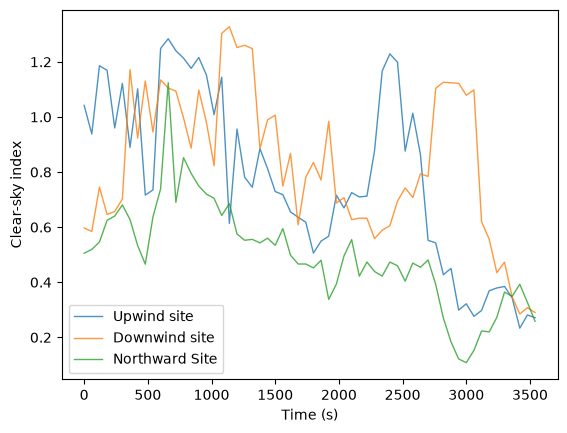

In [7]:
cloud_spd = 1
cloud_dir = 0 * np.pi / 180

# Hourly clearsky
mean_csi = 0.7

e_pos = np.array([ 0, 450, 0])
n_pos = np.array([ 0,   0, 450])

times = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 00:59:59', freq='60s')

c = downscale(times, e_pos, n_pos, cloud_spd, cloud_dir, mean_csi, DEFAULT_PARAMS, seed=42, scale=True, noneg=True)

plt.plot((times-times[0]).total_seconds(), c, linewidth=1, alpha=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Clear-sky index")
plt.legend(['Upwind site', 'Downwind site', 'Northward Site']);


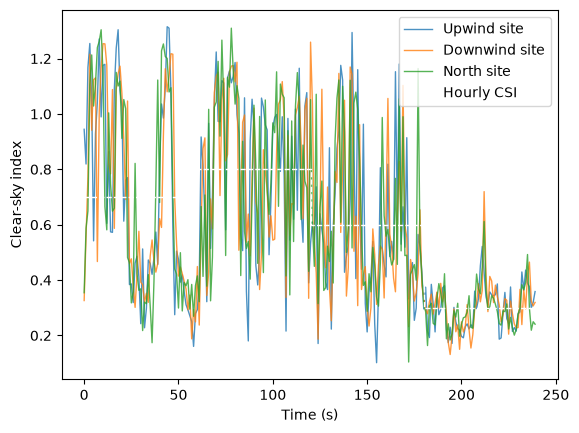

In [9]:
cloud_spd = np.array([5, 30, 25, 15])
cloud_dir = np.zeros_like(cloud_spd)

# Hourly clearsky
mean_csi = np.array([0.7, 0.8, 0.6, 0.3])

e_pos = np.array([ 0, 450, 0])
n_pos = np.array([ 0,   0, 450])

times = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 00:59:59', freq='60s')

c = downscale_multihour(times, e_pos, n_pos, cloud_spd, cloud_dir, mean_csi, DEFAULT_PARAMS, seed=42, scale=True, noneg=True)

csi_block = np.repeat(mean_csi, times.shape[0])

plt.plot(c, alpha=0.8, linewidth=1)
plt.step(np.arange(csi_block.size), csi_block, where='post', color='w', linewidth=1, linestyle='--', label='Hourly CSI')
plt.xlabel("Time (s)")
plt.ylabel("Clear-sky index")
plt.legend(['Upwind site', 'Downwind site', 'North site', 'Hourly CSI']);